<a href="https://colab.research.google.com/github/Nikhildongare123/Brain-Tumor-Detection/blob/main/social_media_addiction_vs_Productivity_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import mean_absolute_error, r2_score

In [ ]:
df = pd.read_csv("/content/social_media_productivity_6000.csv")

In [ ]:
df.head()

,age,daily_screen_time,social_media_hours,study_hours,sleep_hours,notifications_per_day,focus_score,addiction_level,productivity_score
0,21.0,5.95,2.81,2.61,6.99,283.0,100.00,Medium,28.49
1,34.0,3.82,2.33,0.28,7.47,266.0,93.65,Medium,18.54
2,29.0,3.57,1.64,5.21,6.34,137.0,100.00,Low,68.52
3,25.0,10.27,4.37,4.28,4.49,247.0,94.71,Medium,27.82
4,22.0,2.42,1.60,3.67,6.34,28.0,100.00,Low,51.09


In [ ]:
df.isnull().sum()

,0
age,120
daily_screen_time,120
social_media_hours,120
study_hours,120
sleep_hours,120
notifications_per_day,120
focus_score,120
addiction_level,120
productivity_score,120


In [ ]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [ ]:
df.isnull().sum()

,0
age,0
daily_screen_time,0
social_media_hours,0
study_hours,0
sleep_hours,0
notifications_per_day,0
focus_score,0
addiction_level,0
productivity_score,0


In [ ]:
le = LabelEncoder()
df['addiction_level'] = le.fit_transform(df['addiction_level'])

In [ ]:
df.describe()

,age,daily_screen_time,social_media_hours,study_hours,sleep_hours,notifications_per_day,focus_score,addiction_level,productivity_score
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,27.111395,6.923175,4.145915,4.069328,6.514270,159.781463,96.363531,1.241167,37.614051
std,7.195367,2.830315,2.133829,2.286257,1.419933,80.229989,7.342283,0.917685,27.325777
min,15.000000,2.000000,0.660000,0.000000,4.000000,20.000000,47.390000,0.000000,0.000000
25%,21.000000,4.520000,2.430000,2.160000,5.300000,90.000000,96.363531,0.000000,14.310000
50%,27.000000,6.923175,3.815000,4.069328,6.514270,159.781463,100.000000,2.000000,37.100000
75%,33.000000,9.312500,5.490000,6.000000,7.700000,230.000000,100.000000,2.000000,58.135000
max,39.000000,11.990000,10.660000,8.000000,9.000000,299.000000,100.000000,3.000000,100.000000


## 📊 1. Data Visualization (Matplotlib)

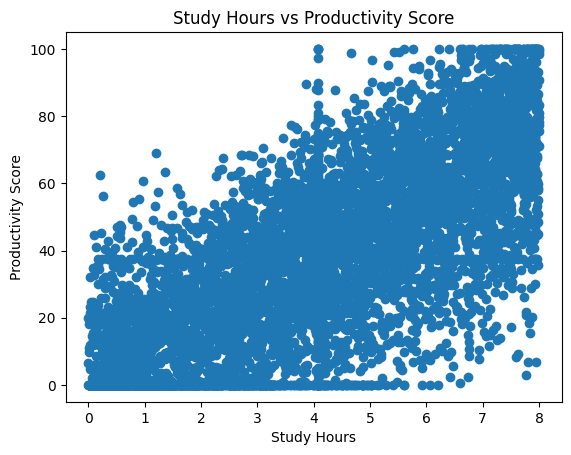

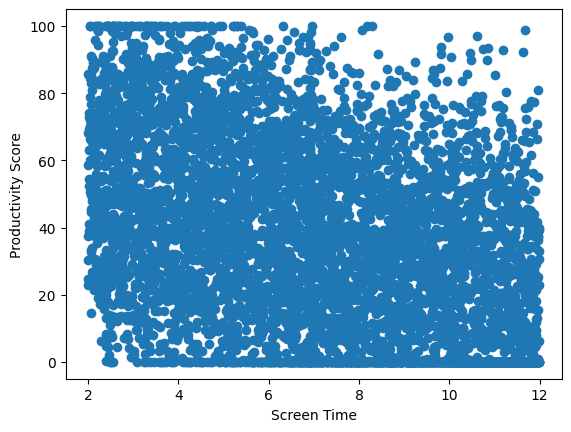

In [ ]:
plt.scatter(df['study_hours'],df['productivity_score'])
plt.xlabel('Study Hours')
plt.ylabel('Productivity Score')
plt.title('Study Hours vs Productivity Score')
plt.show()
# Screen Time vs Productivity
plt.scatter(df['daily_screen_time'], df['productivity_score'])
plt.xlabel("Screen Time")
plt.ylabel("Productivity Score")
plt.show()

In [14]:
df.columns

Index(['age', 'daily_screen_time', 'social_media_hours', 'study_hours',
       'sleep_hours', 'notifications_per_day', 'focus_score',
       'addiction_level', 'productivity_score'],
      dtype='object')

In [18]:
x = df[['age', 'daily_screen_time', 'social_media_hours', 'study_hours',
       'sleep_hours', 'notifications_per_day', 'focus_score',
       'addiction_level']]
y = df['productivity_score']
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2)

In [25]:

le_model = LinearRegression()

In [26]:
le_model.fit(x_train, y_train)


LinearRegression()

In [28]:
y_pred = le_model.predict(x_test)

In [29]:
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("R2 Score:", r2)

MAE: 8.197696178100255
R2 Score: 0.8429225938018587


⭐Feature Importance

In [31]:
importance = le_model.coef_

for i, col in enumerate(x.columns):
    print(col, ":", importance[i])

age : 0.00512249780557415
daily_screen_time : -0.31530262475412774
social_media_hours : -7.076023964967513
study_hours : 9.352652177001909
sleep_hours : 4.7232375075576565
notifications_per_day : -0.032120411766761614
focus_score : -0.5688765165026668
addiction_level : 0.45796608968482566


In [34]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=100)
rf.fit(x_train, y_train)

y_pred_rf = rf.predict(x_test)

from sklearn.metrics import r2_score
print("Random Forest R2:", r2_score(y_test, y_pred_rf))

Random Forest R2: 0.8415404990986499


In [36]:
importances = rf.feature_importances_

for i, col in enumerate(x.columns):
    print(col, ":", importances[i])

age : 0.017707614897698343
daily_screen_time : 0.026361422607207773
social_media_hours : 0.13357073721199134
study_hours : 0.3035314435827285
sleep_hours : 0.05976012622741455
notifications_per_day : 0.025190431005861956
focus_score : 0.4293096234604691
addiction_level : 0.004568601006628463


In [39]:
import pickle
pickle.dump(rf, open("model.pkl", "wb"))